<a href="https://colab.research.google.com/github/VladaNedelceva/spotify-song-popularity-prediction/blob/main/Spotify_Song_Popularity_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importarea librariilor si a datelor


# Secțiune nouă

In [ ]:
import pandas as pd
from datetime import datetime as dt
from matplotlib.cbook import boxplot_stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

In [ ]:
spotify = pd.read_csv('https://girlsgoitpublic.z6.web.core.windows.net/spotify.csv')
spotify

,Unnamed: 0,Track ID,track_name,track_artist,lyrics,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,language,popular
0,0,0017A6SJgTbfQVU2EtsPNo,Pangarap,Barbie's Cradle,Minsan pa Nang ako'y napalingon Hindi ko alam ...,41,1srJQ0njEQgd8w4XSqI4JQ,Trip,2001-01-01,Pinoy Classic Rock,...,1,0.0236,0.27900,0.011700,0.0887,0.566,97.091,235440,tl,0
1,1,004s3t0ONYlzxII9PLgU6z,I Feel Alive,Steady Rollin,"The trees, are singing in the wind The sky blu...",28,3z04Lb9Dsilqw68SHt6jLB,Love & Loss,2017-11-21,Hard Rock Workout,...,1,0.0442,0.01170,0.009940,0.3470,0.404,135.225,373512,en,0
2,2,00chLpzhgVjxs1zKC9UScL,Poison,Bell Biv DeVoe,"NA Yeah, Spyderman and Freeze in full effect U...",0,6oZ6brjB8x3GoeSYdwJdPc,Gold,2005-01-01,"Back in the day - R&B, New Jack Swing, Swingbe...",...,0,0.2160,0.00432,0.007230,0.4890,0.650,111.904,262467,en,0
3,3,00cqd6ZsSkLZqGMlQCR0Zo,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,I really can't stay Baby it's cold outside I'v...,41,3ssspRe42CXkhPxdc12xcp,CeeLo's Magic Moment,2012-10-29,Christmas Soul,...,0,0.0341,0.68900,0.000000,0.0664,0.405,118.593,243067,en,0
4,4,00emjlCv9azBN0fzuuyLqy,Dumb Litty,KARD,Get up out of my business You don't keep me fr...,65,7h5X3xhh3peIK9Y0qI5hbK,KARD 2nd Digital Single ‘Dumb Litty’,2019-09-22,K-Party Dance Mix,...,1,0.0409,0.03700,0.000000,0.1380,0.240,130.018,193160,en,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18449,18449,7zXzWCVuz7whIuYZyEAlxt,Rising Like The Sun - Radio Mix,Qulinez,"Caught up in such a head rush, wide-eyed latel...",0,1l4aoukbPgi5u2OaE2R4Zj,Rising Like The Sun,2014-03-24,♥ EDM LOVE 2020,...,0,0.0878,0.00555,0.000000,0.3350,0.211,128.012,208656,en,0
18450,18450,7zycSpvjDcqh6YT1FEl2kY,Anaconda,Nicki Minaj,"My anaconda don't, my anaconda don't My anacon...",49,5qs8T6ZHSrnllnOuUk6muC,The Pinkprint (Deluxe Edition),2014-12-15,10er Playlist,...,1,0.1800,0.06730,0.000006,0.2140,0.647,129.99,260240,en,1
18451,18451,7zye9v6B785eFWEFYs13C2,Bound,Ponderosa Twins Plus One,"Bound, bound Bound, bound Bound to fall in lov...",40,1xdgLmTFMSyJyI5DJOOX7T,2+2+1 = (Digitally Remastered),2013-07-09,Sexy Soul 2020,...,0,0.0270,0.71500,0.000428,0.1150,0.657,142.218,191205,en,0
18452,18452,7zyLObYw4QUKQDyZOb4J0Y,I'll Do 4 U (Re-Recorded / Remastered),Father MC,(Would you do for me) Sweetheart (Would you do...,36,14HYMxFhpgDIr9cci1u0kt,I'll Do 4 U (Re-Recorded / Remastered),2010-10-01,New Jack Swing/ R&B Hits: 1987 - 2002,...,0,0.0633,0.14300,0.000000,0.0720,0.810,109.536,223890,en,0


# Curățarea datelor

In [ ]:
spotify.drop(['Unnamed: 0', 'Track ID', 'track_album_id','playlist_id', 'playlist_subgenre','playlist_name','mode','acousticness', 'instrumentalness','lyrics','track_popularity','track_album_name','track_name','track_artist'],axis=1, inplace=True)
spotify

,track_album_release_date,Playlist Genre,danceability,energy,KEY,loudness,speechiness,liveness,valence,tempo,duration_ms,language,popular
0,2001-01-01,rock,0.682,0.401,2,-10.068,0.0236,0.0887,0.566,97.091,235440,tl,0
1,2017-11-21,rock,0.303,0.880,9,-4.739,0.0442,0.3470,0.404,135.225,373512,en,0
2,2005-01-01,r&b,0.845,0.652,6,-7.504,0.2160,0.4890,0.650,111.904,262467,en,0
3,2012-10-29,r&b,0.425,0.378,5,-5.819,0.0341,0.0664,0.405,118.593,243067,en,0
4,2019-09-22,pop,0.760,0.887,9,-1.993,0.0409,0.1380,0.240,130.018,193160,en,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18449,2014-03-24,edm,0.479,0.800,10,-5.778,0.0878,0.3350,0.211,128.012,208656,en,0
18450,2014-12-15,pop,0.963,0.603,2,-6.224,0.1800,0.2140,0.647,129.99,260240,en,1
18451,2013-07-09,r&b,0.458,0.540,5,-6.457,0.0270,0.1150,0.657,142.218,191205,en,0
18452,2010-10-01,r&b,0.832,0.666,1,-4.920,0.0633,0.0720,0.810,109.536,223890,en,0


In [ ]:
spotify.columns=spotify.columns.str.replace(' ','_').str.lower()
spotify.columns

Index(['track_album_release_date', 'playlist_genre', 'danceability', 'energy',
       'key', 'loudness', 'speechiness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'language', 'popular'],
      dtype='object')

In [ ]:
spotify.isnull().sum()

track_album_release_date      0
playlist_genre                0
danceability                  0
energy                        0
key                           0
loudness                    134
speechiness                   0
liveness                      0
valence                       0
tempo                        68
duration_ms                   0
language                    260
popular                       0
dtype: int64

In [ ]:
spotify['tempo']=spotify['tempo'].str.replace('%','').astype('float')

In [ ]:
spotify['tempo'].value_counts()

127.997    15
127.994    15
128.001    14
128.000    14
128.007    13
           ..
131.337     1
72.577      1
91.625      1
115.073     1
115.049     1
Name: tempo, Length: 13358, dtype: int64

In [ ]:
mean_tempo=spotify['tempo'].mean()
spotify['tempo'].fillna(mean_tempo, inplace=True)

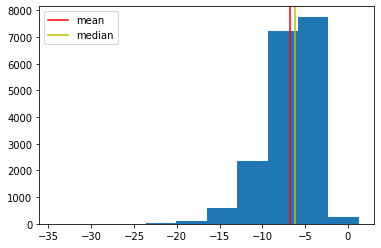

In [ ]:
plt.hist(spotify['loudness']);
plt.axvline(spotify['loudness'].mean(), color='r', label = "mean")
plt.axvline(spotify['loudness'].median(), color='y', label = "median")
plt.legend()

In [ ]:
mean_loudness=spotify['loudness'].mean()
spotify['loudness'].fillna(mean_loudness, inplace=True)

In [ ]:
spotify.head()

,track_album_release_date,playlist_genre,danceability,energy,key,loudness,speechiness,liveness,valence,tempo,duration_ms,language,popular
0,2001-01-01,rock,0.682,0.401,2,-10.068,0.0236,0.0887,0.566,97.091,235440,tl,0
1,2017-11-21,rock,0.303,0.880,9,-4.739,0.0442,0.3470,0.404,135.225,373512,en,0
2,2005-01-01,r&b,0.845,0.652,6,-7.504,0.2160,0.4890,0.650,111.904,262467,en,0
3,2012-10-29,r&b,0.425,0.378,5,-5.819,0.0341,0.0664,0.405,118.593,243067,en,0
4,2019-09-22,pop,0.760,0.887,9,-1.993,0.0409,0.1380,0.240,130.018,193160,en,1


In [ ]:
spotify['track_album_release_date'] = pd.to_datetime(spotify['track_album_release_date'])
spotify['track_album_release_date'] = spotify['track_album_release_date'].dt.strftime('%Y')
spotify['track_album_release_date'] = spotify['track_album_release_date'].astype('int')

In [ ]:
spotify.duplicated(keep=False)
spotify[spotify.duplicated(keep=False)]

,track_album_release_date,playlist_genre,danceability,energy,key,loudness,speechiness,liveness,valence,tempo,duration_ms,language,popular
124,2010,rap,0.760,0.595,1,-6.366,0.0391,0.2410,0.361,131.497,263773,en,1
214,2014,edm,0.614,0.972,5,-3.927,0.0880,0.3280,0.411,127.966,170625,en,1
243,2019,pop,0.740,0.498,11,-6.684,0.0456,0.3190,0.652,98.016,207039,en,1
326,2016,edm,0.512,0.915,11,-5.377,0.1360,0.5230,0.288,130.050,195692,en,0
346,2007,rock,0.424,0.632,9,-7.243,0.0922,0.0545,0.356,97.694,254533,en,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18083,1989,r&b,0.799,0.621,7,-12.762,0.0681,0.0913,0.663,114.120,232293,en,0
18194,2017,pop,0.736,0.795,1,-3.299,0.0545,0.2540,0.511,104.066,230813,en,1
18219,2015,latin,0.694,0.955,9,-2.872,0.0676,0.1380,0.713,123.982,227709,en,0
18353,2010,pop,0.615,0.711,11,-5.507,0.0779,0.1450,0.711,144.036,221253,en,1


In [ ]:
spotify.drop_duplicates(keep='first', inplace=True)

In [ ]:
spotify[spotify.duplicated(keep=False)]

,track_album_release_date,playlist_genre,danceability,energy,key,loudness,speechiness,liveness,valence,tempo,duration_ms,language,popular


In [ ]:
spotify.shape

(18301, 13)

In [ ]:
spotify.head()

,track_album_release_date,playlist_genre,danceability,energy,key,loudness,speechiness,liveness,valence,tempo,duration_ms,language,popular
0,2001,rock,0.682,0.401,2,-10.068,0.0236,0.0887,0.566,97.091,235440,tl,0
1,2017,rock,0.303,0.880,9,-4.739,0.0442,0.3470,0.404,135.225,373512,en,0
2,2005,r&b,0.845,0.652,6,-7.504,0.2160,0.4890,0.650,111.904,262467,en,0
3,2012,r&b,0.425,0.378,5,-5.819,0.0341,0.0664,0.405,118.593,243067,en,0
4,2019,pop,0.760,0.887,9,-1.993,0.0409,0.1380,0.240,130.018,193160,en,1


In [ ]:
spotify['playlist_genre']=spotify['playlist_genre'].str.lower()
spotify['playlist_genre'].value_counts()

pop      3944
rock     3490
rap      3382
r&b      3302
latin    2163
edm      2020
Name: playlist_genre, dtype: int64

In [ ]:
spotify['language']

0        tl
1        en
2        en
3        en
4        en
         ..
18449    en
18450    en
18451    en
18452    en
18453    tl
Name: language, Length: 18301, dtype: object

# Înlocuirea datelor

In [ ]:
languages_list = spotify['language'].unique().tolist()
for element in ['en', 'es']:
  languages_list.remove(element)
  languages_list

In [ ]:
spotify.loc[spotify['language'].isin(languages_list), 'language'] = 'other'

In [ ]:
spotify['language'].value_counts()

en       15262
es        1699
other     1340
Name: language, dtype: int64


# Dummies

In [ ]:
dummies = pd.get_dummies(spotify[['language']], drop_first = True)
dummies


,language_es,language_other
0,0,1
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
18449,0,0
18450,0,0
18451,0,0
18452,0,0


In [ ]:
dummie = pd.get_dummies(spotify['playlist_genre'], drop_first = True)
dummie


,latin,pop,r&b,rap,rock
0,0,0,0,0,1
1,0,0,0,0,1
2,0,0,1,0,0
3,0,0,1,0,0
4,0,1,0,0,0
...,...,...,...,...,...
18449,0,0,0,0,0
18450,0,1,0,0,0
18451,0,0,1,0,0
18452,0,0,1,0,0


In [ ]:
spotify_dummies = pd.concat([spotify, dummies, dummie], axis = 1)
spotify_dummies

,track_album_release_date,playlist_genre,danceability,energy,key,loudness,speechiness,liveness,valence,tempo,duration_ms,language,popular,language_es,language_other,latin,pop,r&b,rap,rock
0,2001,rock,0.682,0.401,2,-10.068,0.0236,0.0887,0.566,97.091,235440,other,0,0,1,0,0,0,0,1
1,2017,rock,0.303,0.880,9,-4.739,0.0442,0.3470,0.404,135.225,373512,en,0,0,0,0,0,0,0,1
2,2005,r&b,0.845,0.652,6,-7.504,0.2160,0.4890,0.650,111.904,262467,en,0,0,0,0,0,1,0,0
3,2012,r&b,0.425,0.378,5,-5.819,0.0341,0.0664,0.405,118.593,243067,en,0,0,0,0,0,1,0,0
4,2019,pop,0.760,0.887,9,-1.993,0.0409,0.1380,0.240,130.018,193160,en,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18449,2014,edm,0.479,0.800,10,-5.778,0.0878,0.3350,0.211,128.012,208656,en,0,0,0,0,0,0,0,0
18450,2014,pop,0.963,0.603,2,-6.224,0.1800,0.2140,0.647,129.990,260240,en,1,0,0,0,1,0,0,0
18451,2013,r&b,0.458,0.540,5,-6.457,0.0270,0.1150,0.657,142.218,191205,en,0,0,0,0,0,1,0,0
18452,2010,r&b,0.832,0.666,1,-4.920,0.0633,0.0720,0.810,109.536,223890,en,0,0,0,0,0,1,0,0


# Crearea modelului (features, X & y values)

In [ ]:
features = ["track_album_release_date",'danceability','energy','key','loudness','speechiness','liveness','valence','tempo','duration_ms','language_es','language_other','latin','pop','r&b','rap','rock']

In [ ]:
X = spotify_dummies[features]# features
y = spotify_dummies['popular']#target

In [ ]:
!pip install catboost

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from catboost import CatBoostClassifier

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.35, random_state=37)

In [ ]:
model = CatBoostClassifier(depth=5,random_seed=1,text_processing=1,random_strength=1)
model.fit(X_train, y_train)

Learning rate set to 0.029656
0:	learn: 0.6909743	total: 6.15ms	remaining: 6.14s
1:	learn: 0.6889223	total: 11.4ms	remaining: 5.67s
2:	learn: 0.6870592	total: 18ms	remaining: 5.98s
3:	learn: 0.6852164	total: 22.9ms	remaining: 5.71s
4:	learn: 0.6835844	total: 29.1ms	remaining: 5.79s
5:	learn: 0.6818538	total: 34.1ms	remaining: 5.65s
6:	learn: 0.6801485	total: 40.6ms	remaining: 5.76s
7:	learn: 0.6789781	total: 46.9ms	remaining: 5.82s
8:	learn: 0.6773663	total: 55.1ms	remaining: 6.07s
9:	learn: 0.6763048	total: 60.1ms	remaining: 5.95s
10:	learn: 0.6749687	total: 66.2ms	remaining: 5.95s
11:	learn: 0.6735189	total: 72ms	remaining: 5.93s
12:	learn: 0.6722250	total: 77.1ms	remaining: 5.85s
13:	learn: 0.6714281	total: 96.6ms	remaining: 6.8s
14:	learn: 0.6704840	total: 111ms	remaining: 7.3s
15:	learn: 0.6692534	total: 118ms	remaining: 7.23s
16:	learn: 0.6680500	total: 123ms	remaining: 7.12s
17:	learn: 0.6669777	total: 128ms	remaining: 6.96s
18:	learn: 0.6661986	total: 134ms	remaining: 6.9s
19:	

In [ ]:
y_predict = model.predict(X_test)

# Evaluarea modelului (accuracy.score...etc.)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

In [ ]:
accuracy_score(y_predict, y_test)

0.6548548236028723

In [ ]:
precision_score(y_predict, y_test, pos_label=0)

0.6698824238769973

In [ ]:
recall_score(y_predict, y_test, pos_label=0)

0.6656680647094069

In [ ]:
f1_score(y_predict, y_test, pos_label=0)

0.6677685950413222

In [ ]:
conf_mx = confusion_matrix(y_test, y_predict)

(array([0.5, 1.5]), <a list of 2 Text major ticklabel objects>)

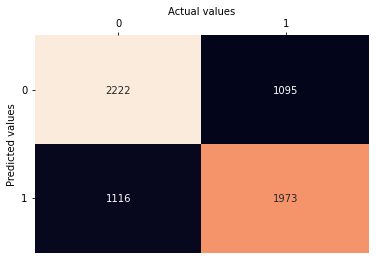

In [ ]:
ax = sns.heatmap(conf_mx, annot=True, fmt="d", cbar=False)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xlabel('Actual values')
ax.set_ylabel('Predicted values')
plt.yticks(rotation=0)